# XXX-цепочка спинов 1/2: энергия основного состояния

Для всех целых $N=3,\ldots,26$ рассчитываем открытые (ОГУ) и периодические
(ПГУ) границы. Полагаем $J=1$ и

$$H=\sum_{(i,j)\in B}\mathbf S_i\cdot\mathbf S_j
=\sum_{(i,j)\in B}\left[S_i^z S_j^z+
\frac12(S_i^+S_j^-+S_i^-S_j^+)\right],\qquad S^\alpha=\frac{\sigma^\alpha}{2}.$$

Для ОГУ $B=\{(1,2),\ldots,(N-1,N)\}$; для ПГУ добавляется $(N,1)$.
Искомая удельная энергия $e_0(N)=E_0(N)/N$ сравнивается с
$e_\infty=1/4-\ln2$. В обозначениях приложенного конспекта
$H=-J_{\rm конспект}\sum\mathbf S_i\cdot\mathbf S_j$ это соответствует
$J_{\rm конспект}=-1$.

## Базис и метод

Состояние кодируется битовой строкой: бит 1 означает спин вверх.
Оператор $H$ сохраняет $S^z_{\rm total}=n_\uparrow-N/2$. Для чётного $N$
используем $n_\uparrow=N/2$; для нечётного $n_\uparrow=(N-1)/2$,
то есть $S^z_{\rm total}=-1/2$. Сектор $+1/2$ имеет ту же энергию из-за
одновременного переворота всех спинов.

Для каждой связи параллельных спинов диагональный вклад равен $+1/4$;
антипараллельных — $-1/4$. Перестановка антипараллельных спинов даёт
внедиагональный элемент $+1/2$. Numba формирует разреженную матрицу CSR
блоками; `scipy.sparse.linalg.eigsh(k=1, which="SA")` ищет нижний уровень.
Проверяем невязку $\|H\psi-E_0\psi\|_2$, норму $\psi$ и повторный запуск
с другим начальным вектором. Подробный вывод — в `docs/theory.md`.

In [1]:
import csv
import sys
from math import comb
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data"
CASES = DATA / "cases"
DATA.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from tqdm.auto import tqdm
from result_store import SOURCE_HASH, load_case, load_grid, write_case
from xxx_chain import ground_state

SIZES = tuple(range(3, 27))
E_INFINITY = 0.25 - np.log(2.0)
print(f"48 случаев; аналитический предел: {E_INFINITY:.12f}")

48 случаев; аналитический предел: -0.443147180560


In [2]:
cached, missing = load_grid(CASES, SIZES)
print(f"Проверенных контейнерных результатов: {len(cached)}; требуется вычислить: {len(missing)}")
for n, periodic in tqdm(missing, desc="Недостающие цепочки"):
    row = ground_state(n, periodic, progress=True, repeat=True)
    write_case(CASES, row)

results = [load_case(CASES, n, boundary)
           for n in SIZES for boundary in ("OBC", "PBC")]
assert len(results) == 48 and all(row is not None for row in results)
assert {(int(row["N"]), str(row["boundary"])) for row in results} == {
    (n, boundary) for n in SIZES for boundary in ("OBC", "PBC")}
fields = ("N", "boundary", "n_up", "sz_total", "dimension", "nnz", "E0", "e0",
          "residual", "norm_error", "repeat_delta", "csr_gib")
with (DATA / "results.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=fields, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results)
print("Сохранено: data/results.csv")

Проверенных контейнерных результатов: 48; требуется вычислить: 0


Недостающие цепочки: 0it [00:00, ?it/s]

Сохранено: data/results.csv


In [3]:
lines = [r"| N | ГУ | $n_\uparrow$ | Размер блока | $E_0$ | $E_0/N$ | Невязка | $|\Delta E|$ повтора |",
         "|---:|:---:|---:|---:|---:|---:|---:|---:|"]
for row in results:
    lines.append(f"| {row['N']} | {row['boundary']} | {row['n_up']} | "
                 f"{row['dimension']:,} | {row['E0']:.10f} | {row['e0']:.10f} | "
                 f"{row['residual']:.2e} | {row['repeat_delta']:.2e} |")
display(Markdown("\n".join(lines)))

| N | ГУ | $n_\uparrow$ | Размер блока | $E_0$ | $E_0/N$ | Невязка | $|\Delta E|$ повтора |
|---:|:---:|---:|---:|---:|---:|---:|---:|
| 3 | OBC | 1 | 3 | -1.0000000000 | -0.3333333333 | 1.57e-16 | 0.00e+00 |
| 3 | PBC | 1 | 3 | -0.7500000000 | -0.2500000000 | 2.81e-16 | 0.00e+00 |
| 4 | OBC | 2 | 6 | -1.6160254038 | -0.4040063509 | 5.10e-16 | 4.44e-16 |
| 4 | PBC | 2 | 6 | -2.0000000000 | -0.5000000000 | 4.97e-16 | 4.44e-16 |
| 5 | OBC | 2 | 10 | -1.9278862533 | -0.3855772507 | 7.07e-16 | 4.44e-16 |
| 5 | PBC | 2 | 10 | -1.8680339887 | -0.3736067977 | 5.52e-16 | 6.66e-16 |
| 6 | OBC | 3 | 20 | -2.4935771339 | -0.4155961890 | 1.78e-15 | 8.88e-16 |
| 6 | PBC | 3 | 20 | -2.8027756377 | -0.4671292730 | 1.69e-15 | 1.78e-15 |
| 7 | OBC | 3 | 35 | -2.8362396807 | -0.4051770972 | 2.89e-15 | 2.66e-15 |
| 7 | PBC | 3 | 35 | -2.8551792568 | -0.4078827510 | 1.99e-15 | 8.88e-16 |
| 8 | OBC | 4 | 70 | -3.3749325987 | -0.4218665748 | 9.35e-12 | 2.66e-15 |
| 8 | PBC | 4 | 70 | -3.6510934089 | -0.4563866761 | 8.89e-14 | 0.00e+00 |
| 9 | OBC | 4 | 126 | -3.7363217064 | -0.4151468563 | 9.84e-15 | 1.78e-15 |
| 9 | PBC | 4 | 126 | -3.7972997839 | -0.4219221982 | 4.32e-12 | 5.33e-15 |
| 10 | OBC | 5 | 252 | -4.2580352073 | -0.4258035207 | 3.18e-12 | 1.78e-15 |
| 10 | PBC | 5 | 252 | -4.5154463545 | -0.4515446354 | 7.26e-14 | 8.88e-16 |
| 11 | OBC | 5 | 462 | -4.6320933024 | -0.4210993911 | 1.89e-14 | 9.77e-15 |
| 11 | PBC | 5 | 462 | -4.7189363625 | -0.4289942148 | 1.12e-12 | 3.55e-15 |
| 12 | OBC | 6 | 924 | -5.1420906328 | -0.4285075527 | 6.41e-13 | 0.00e+00 |
| 12 | PBC | 6 | 924 | -5.3873909174 | -0.4489492431 | 4.49e-14 | 4.44e-15 |
| 13 | OBC | 6 | 1,716 | -5.5253220971 | -0.4250247767 | 3.44e-11 | 0.00e+00 |
| 13 | PBC | 6 | 1,716 | -5.6295843297 | -0.4330449484 | 1.16e-13 | 1.60e-14 |
| 14 | OBC | 7 | 3,432 | -6.0267246619 | -0.4304803330 | 1.72e-12 | 1.07e-14 |
| 14 | PBC | 7 | 3,432 | -6.2635495335 | -0.4473963953 | 5.50e-11 | 1.78e-15 |
| 15 | OBC | 7 | 6,435 | -6.4169204918 | -0.4277946995 | 2.06e-11 | 1.42e-14 |
| 15 | PBC | 7 | 6,435 | -6.5336675725 | -0.4355778382 | 3.12e-11 | 3.55e-15 |
| 16 | OBC | 8 | 12,870 | -6.9117371456 | -0.4319835716 | 3.05e-12 | 7.11e-15 |
| 16 | PBC | 8 | 12,870 | -7.1422963606 | -0.4463935225 | 1.15e-11 | 1.07e-14 |
| 17 | OBC | 8 | 24,310 | -7.3074087080 | -0.4298475711 | 3.63e-11 | 6.22e-15 |
| 17 | PBC | 8 | 24,310 | -7.4335201653 | -0.4372658921 | 1.60e-11 | 1.51e-14 |
| 18 | OBC | 9 | 48,620 | -7.7970110685 | -0.4331672816 | 3.38e-11 | 3.55e-15 |
| 18 | PBC | 9 | 48,620 | -8.0227490870 | -0.4457082826 | 1.89e-12 | 1.42e-14 |
| 19 | OBC | 9 | 92,378 | -8.1971057416 | -0.4314266180 | 6.67e-13 | 2.66e-14 |
| 19 | PBC | 9 | 92,378 | -8.3304884543 | -0.4384467608 | 8.27e-11 | 1.78e-14 |
| 20 | OBC | 10 | 184,756 | -8.6824733344 | -0.4341236667 | 1.00e-11 | 7.11e-15 |
| 20 | PBC | 10 | 184,756 | -8.9043865299 | -0.4452193265 | 8.88e-13 | 4.62e-14 |
| 21 | OBC | 10 | 352,716 | -9.0862184009 | -0.4326770667 | 8.97e-11 | 2.13e-14 |
| 21 | PBC | 10 | 352,716 | -9.2254029822 | -0.4393049039 | 2.64e-11 | 1.78e-14 |
| 22 | OBC | 11 | 705,432 | -9.5680758760 | -0.4349125398 | 1.88e-11 | 5.15e-14 |
| 22 | PBC | 11 | 705,432 | -9.7868806518 | -0.4448582114 | 2.52e-12 | 7.11e-15 |
| 23 | OBC | 11 | 1,352,078 | -9.9748868054 | -0.4336907307 | 8.15e-12 | 1.07e-14 |
| 23 | PBC | 11 | 1,352,078 | -10.1188036793 | -0.4399479861 | 1.04e-11 | 1.78e-15 |
| 24 | OBC | 12 | 2,704,156 | -10.4537857604 | -0.4355744067 | 3.98e-11 | 1.07e-14 |
| 24 | PBC | 12 | 2,704,156 | -10.6700145165 | -0.4445839382 | 1.43e-11 | 2.31e-14 |
| 25 | OBC | 12 | 5,200,300 | -10.8632093523 | -0.4345283741 | 1.74e-11 | 1.78e-14 |
| 25 | PBC | 12 | 5,200,300 | -11.0110566424 | -0.4404422657 | 4.16e-12 | 4.44e-14 |
| 26 | OBC | 13 | 10,400,600 | -11.3395796528 | -0.4361376790 | 4.67e-11 | 2.31e-14 |
| 26 | PBC | 13 | 10,400,600 | -11.5536388522 | -0.4443707251 | 3.17e-11 | 5.33e-15 |

## Сходимость и чётность

Для четырёх серий отдельно подгоняем последние четыре точки. Для ОГУ
используем $e_0\approx a+b/N$ (вклад краёв), для ПГУ —
$e_0\approx a+c/N^2$ (без краёв). Вторая модель для нечётных колец
также служит только диагностикой: фрустрация меняет коэффициент поправки.
Изотропная критическая цепочка может иметь логарифмические поправки;
интерсепты на малых $N$ не являются строгим доказательством предела.

In [4]:
fits = {}
fit_lines = [r"| ГУ | Чётность | Использованные N | Оценка $a$ | $a-e_\infty$ |",
             "|:---:|:---:|:---:|---:|---:|"]
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        subset = [row for row in results if row["boundary"] == boundary and row["N"] % 2 == parity][-4:]
        n = np.array([row["N"] for row in subset], dtype=float)
        energy = np.array([row["e0"] for row in subset], dtype=float)
        x = 1/n if boundary == "OBC" else 1/n**2
        slope, intercept = np.polyfit(x, energy, 1)
        fits[(boundary, parity)] = (slope, intercept)
        fit_lines.append(f"| {boundary} | {'чётные' if parity == 0 else 'нечётные'} | "
                         f"{', '.join(map(str, n.astype(int)))} | {intercept:.10f} | "
                         f"{intercept-E_INFINITY:+.3e} |")
display(Markdown("\n".join(fit_lines)))

| ГУ | Чётность | Использованные N | Оценка $a$ | $a-e_\infty$ |
|:---:|:---:|:---:|---:|---:|
| OBC | чётные | 20, 22, 24, 26 | -0.4428480959 | +2.991e-04 |
| OBC | нечётные | 19, 21, 23, 25 | -0.4443634118 | -1.216e-03 |
| PBC | чётные | 20, 22, 24, 26 | -0.4431406397 | +6.541e-06 |
| PBC | нечётные | 19, 21, 23, 25 | -0.4431716613 | -2.448e-05 |

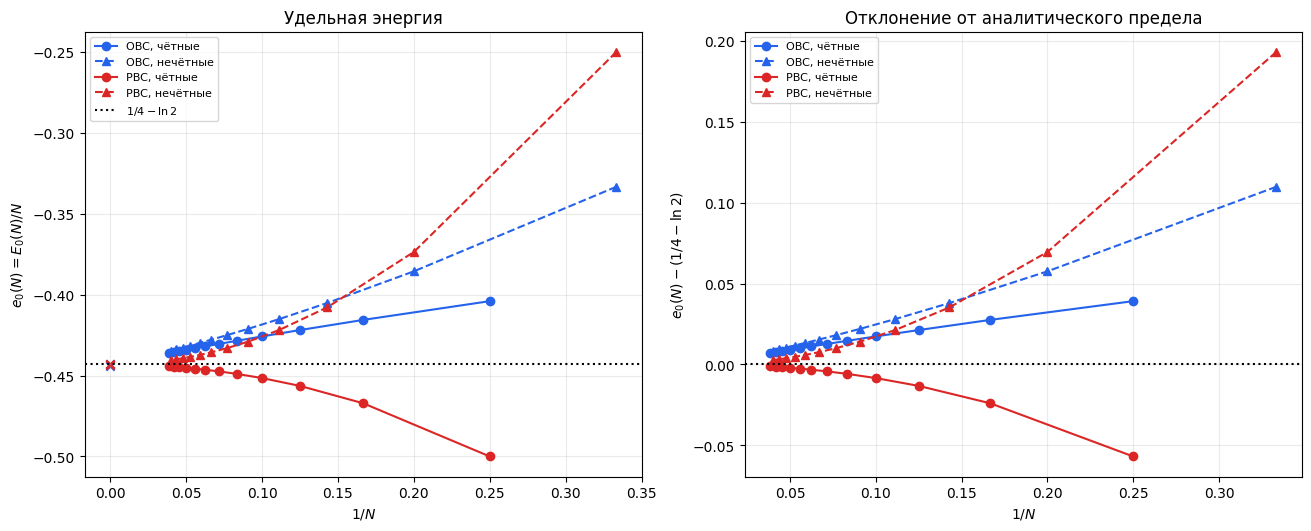

In [5]:
colors = {"OBC": "#2563eb", "PBC": "#dc2626"}
markers = {0: "o", 1: "^"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        subset = [row for row in results if row["boundary"] == boundary and row["N"] % 2 == parity]
        n = np.array([row["N"] for row in subset])
        x = 1 / n
        y = np.array([row["e0"] for row in subset])
        label = f"{boundary}, {'чётные' if parity == 0 else 'нечётные'}"
        axes[0].plot(x, y, marker=markers[parity], color=colors[boundary],
                     linestyle="-" if parity == 0 else "--", label=label)
        axes[1].plot(x, y-E_INFINITY, marker=markers[parity], color=colors[boundary],
                     linestyle="-" if parity == 0 else "--", label=label)
        axes[0].scatter([0], [fits[(boundary, parity)][1]], marker="x", color=colors[boundary])
axes[0].axhline(E_INFINITY, color="black", linestyle=":", label=r"$1/4-\ln2$")
axes[1].axhline(0, color="black", linestyle=":")
axes[0].set_ylabel(r"$e_0(N)=E_0(N)/N$")
axes[1].set_ylabel(r"$e_0(N)-(1/4-\ln2)$")
for ax in axes:
    ax.set_xlabel(r"$1/N$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_title("Удельная энергия")
axes[1].set_title("Отклонение от аналитического предела")
fig.savefig(DATA / "energies.png", dpi=180)
plt.show()

In [6]:
lines = ["### Наблюдаемые закономерности", ""]
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        branch = [row for row in results if row["boundary"] == boundary and row["N"] % 2 == parity]
        last = branch[-1]
        delta = last["e0"] - E_INFINITY
        side = "выше" if delta > 0 else "ниже"
        lines.append(f"- {boundary}, {'чётные' if parity == 0 else 'нечётные'}: "
                     f"при $N={last['N']}$ энергия {side} предела на {abs(delta):.6g}; "
                     f"экстраполяция даёт {fits[(boundary, parity)][1]:.9f}.")
lines += ["", "Открытые концы и замкнутые кольца имеют общий объёмный предел, "
          "но различаются краевыми поправками. Нечётное периодическое кольцо "
          "фрустрировано, поэтому его конечномерная ветвь отличается от чётной. "
          "Наблюдаемое приближение к пределу и приведённые подгонки имеют численный характер."]
display(Markdown("\n".join(lines)))

### Наблюдаемые закономерности

- OBC, чётные: при $N=26$ энергия выше предела на 0.0070095; экстраполяция даёт -0.442848096.
- OBC, нечётные: при $N=25$ энергия выше предела на 0.00861881; экстраполяция даёт -0.444363412.
- PBC, чётные: при $N=26$ энергия ниже предела на 0.00122354; экстраполяция даёт -0.443140640.
- PBC, нечётные: при $N=25$ энергия выше предела на 0.00270491; экстраполяция даёт -0.443171661.

Открытые концы и замкнутые кольца имеют общий объёмный предел, но различаются краевыми поправками. Нечётное периодическое кольцо фрустрировано, поэтому его конечномерная ветвь отличается от чётной. Наблюдаемое приближение к пределу и приведённые подгонки имеют численный характер.

## Проверка уравнения и численного решения

`tests/validate.py` независимо строит гамильтониан из тензорных произведений
матриц Паули при $N=3,\ldots,8$ и сравнивает его со всеми элементами
битового блока и нижним уровнем. Для $N\leq16$ тест проходит все секторы
намагниченности; для каждого расчёта в таблице проверены две стартовые точки
`eigsh`, невязка и нормировка. Точное решение: $E_0(3,\mathrm{ОГУ})=-1$,
$E_0(3,\mathrm{ПГУ})=-3/4$, $E_0(4,\mathrm{ПГУ})=-2$.

In [7]:
by_case = {(row["N"], row["boundary"]): row for row in results}
assert abs(by_case[(3, "OBC")]["E0"] + 1) < 1e-10
assert abs(by_case[(3, "PBC")]["E0"] + 0.75) < 1e-10
assert abs(by_case[(4, "PBC")]["E0"] + 2) < 1e-10
print("Максимальная невязка:", max(row["residual"] for row in results))
print("Максимальная ошибка нормы:", max(row["norm_error"] for row in results))
print("Максимальное расхождение повторов:", max(row["repeat_delta"] for row in results))
partner_path = DATA / "partner_checks.json"
if partner_path.exists():
    import json
    partners = json.loads(partner_path.read_text(encoding="utf-8"))
    if partners.get("source_sha256") == SOURCE_HASH:
        print(f"Партнёрские сектора: {partners['checked_cases']} случаев, "
              f"максимальное расхождение {partners['max_energy_delta']:.3e}")
    else:
        print("Проверка партнёрских секторов устарела; перезапустите scripts/check_partners.py.")
else:
    print("Партнёрские сектора: запустите scripts/check_partners.py для отдельной проверки.")

Максимальная невязка: 8.96993722028208e-11
Максимальная ошибка нормы: 1.340039190722564e-13
Максимальное расхождение повторов: 5.1514348342607263e-14
Партнёрские сектора: 24 случаев, максимальное расхождение 2.665e-14


## Ресурсы Docker

Каждый результат диспетчера измерен в отдельном контейнере: время —
`perf_counter`, CPU — `process_time`, пик памяти процесса — `ru_maxrss`.
Время включает **два** запуска `eigsh` для проверки повторяемости; 100% CPU
соответствует одному занятому ядру. При запуске notebook без диспетчера
энергии вычисляются, но сопоставимых измерений отдельного контейнера нет.
Диспетчер допускает одновременно не более 14 контейнеров и резервирует
30% памяти Docker плюс 0,5 ГиБ на каждый запущенный расчёт.

In [8]:
usage = [row for row in results if "peak_rss_gib" in row]
if usage:
    fields = ("N", "boundary", "dimension", "nnz", "wall_seconds", "cpu_seconds",
              "cpu_percent_one_core", "peak_rss_gib", "csr_gib", "docker_memory_gib")
    with (DATA / "resource_measurements.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(usage)
    lines = ["| N | ГУ | Время, с | CPU, с | CPU, % ядра | Пик RAM, ГиБ | CSR, ГиБ |",
             "|---:|:---:|---:|---:|---:|---:|---:|"]
    for row in usage:
        if row["N"] >= 16 and row["boundary"] == "PBC":
            lines.append(f"| {row['N']} | PBC | {row['wall_seconds']:.2f} | "
                         f"{row['cpu_seconds']:.2f} | {row['cpu_percent_one_core']:.1f} | "
                         f"{row['peak_rss_gib']:.2f} | {row['csr_gib']:.3f} |")
    display(Markdown("\n".join(lines)))
else:
    print("Изолированные замеры отсутствуют; запустите scripts/run_grid.ps1 на Windows.")
benchmark_path = DATA / "benchmark.json"
if benchmark_path.exists():
    import json
    benchmark = json.loads(benchmark_path.read_text(encoding="utf-8-sig"))
    print(f"Выбранный предел параллелизма: {benchmark['chosen_containers']} контейнеров.")
    for measurement in benchmark["measurements"]:
        print(f"лимит {measurement['containers']:2d}: {measurement['wall_seconds']:.2f} с")

| N | ГУ | Время, с | CPU, с | CPU, % ядра | Пик RAM, ГиБ | CSR, ГиБ |
|---:|:---:|---:|---:|---:|---:|---:|
| 16 | PBC | 0.05 | 0.05 | 90.9 | 0.17 | 0.001 |
| 17 | PBC | 0.17 | 0.16 | 90.9 | 0.17 | 0.003 |
| 18 | PBC | 0.73 | 0.66 | 90.0 | 0.19 | 0.006 |
| 19 | PBC | 1.91 | 1.73 | 90.4 | 0.21 | 0.012 |
| 20 | PBC | 4.05 | 3.61 | 89.1 | 0.26 | 0.024 |
| 21 | PBC | 5.94 | 5.32 | 89.6 | 0.36 | 0.049 |
| 22 | PBC | 11.58 | 10.50 | 90.7 | 0.55 | 0.101 |
| 23 | PBC | 15.83 | 14.39 | 90.9 | 0.94 | 0.201 |
| 24 | PBC | 32.64 | 29.67 | 90.9 | 1.77 | 0.409 |
| 25 | PBC | 58.96 | 53.60 | 90.9 | 3.37 | 0.833 |
| 26 | PBC | 133.38 | 121.25 | 90.9 | 6.80 | 1.726 |

Выбранный предел параллелизма: 8 контейнеров.
лимит  1: 57.63 с
лимит  2: 30.27 с
лимит  4: 18.98 с
лимит  8: 13.61 с
лимит 14: 15.29 с


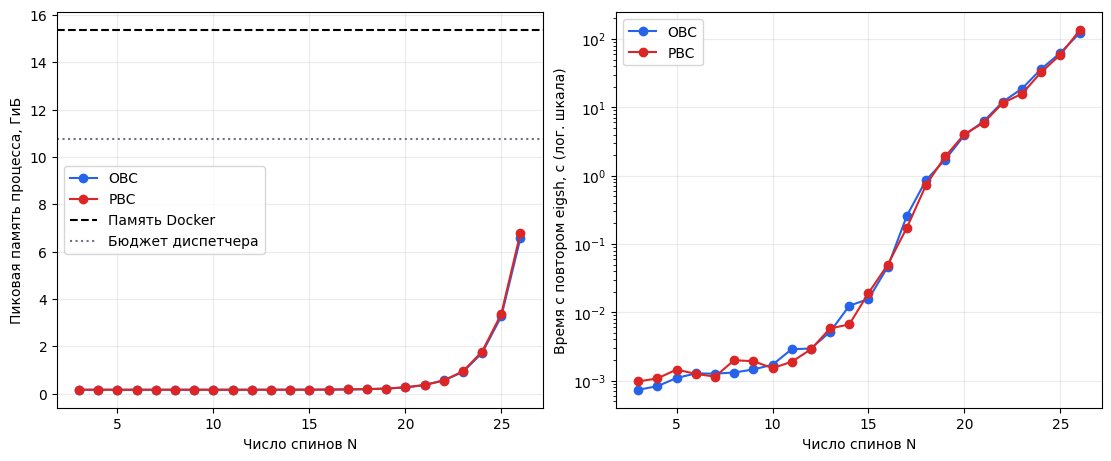

Docker: 15.34 ГиБ; N=26: пик 6.80 ГиБ (измерено); N=28: около 28.0 ГиБ (оценка, не измерение).
Подтверждённый максимум текущего кода — N=26; N=27 не тестировался и пока не поддерживается.


In [9]:
if usage:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    for boundary in ("OBC", "PBC"):
        branch = [row for row in usage if row["boundary"] == boundary]
        axes[0].plot([row["N"] for row in branch], [row["peak_rss_gib"] for row in branch],
                     marker="o", color=colors[boundary], label=boundary)
        axes[1].semilogy([row["N"] for row in branch], [row["wall_seconds"] for row in branch],
                        marker="o", color=colors[boundary], label=boundary)
    docker_gib = usage[0]["docker_memory_gib"]
    axes[0].axhline(docker_gib, color="black", linestyle="--", label="Память Docker")
    axes[0].axhline(0.70*docker_gib, color="#6b7280", linestyle=":", label="Бюджет диспетчера")
    axes[0].set_ylabel("Пиковая память процесса, ГиБ")
    axes[1].set_ylabel("Время с повтором eigsh, с (лог. шкала)")
    for ax in axes:
        ax.set_xlabel("Число спинов N")
        ax.grid(alpha=0.25)
        ax.legend()
    fig.savefig(DATA / "resource_usage.png", dpi=180)
    plt.show()
    peak26 = max(row["peak_rss_gib"] for row in usage if row["N"] == 26)
    def candidates(n):
        k = n // 2
        return comb(n, k) + 2*n*comb(n-2, k-1)
    estimate28 = peak26 * candidates(28) / candidates(26)
    print(f"Docker: {docker_gib:.2f} ГиБ; N=26: пик {peak26:.2f} ГиБ (измерено); "
          f"N=28: около {estimate28:.1f} ГиБ (оценка, не измерение).")
    print("Подтверждённый максимум текущего кода — N=26; N=27 не тестировался и пока не поддерживается.")